# Bootstrapping

<div style="font-size: 20px;">
The scenario:<br> 

Your company wants to study how advertising spend (X) affects sales (Y). You can use linear regression to describe an equation like $$Y = \beta_0 + \beta_1 * X$$
    
But the question is whether $\beta_0$ and $\beta_1$ might be wrong, and by how much? Let's use bootstrapping to answer this question.
</div>

In [ ]:
# What if model is not linear?
# What if the epsilon term contains a constant or linear term in X?
# What if there are other factors?
y = beta_0 + beta_1 * X + 1 + eps # Z could be the noise (if I can't measure it)
y = beta_0 + beta_1 * X + X**2
y = beta_0 + beta_1 * X + 2 * X
y = (beta_0 + 1) + beta_1 * X + eps
# What if Z is correlated with X?

True pattern:
  Intercept = 3.0000
  Slope     = 2.5000
Original fit:
  Intercept = 3.9581
  Slope     = 2.2168

Bootstrap standard errors:
  SE(Intercept) = 1.1651
  SE(Slope)     = 0.1935


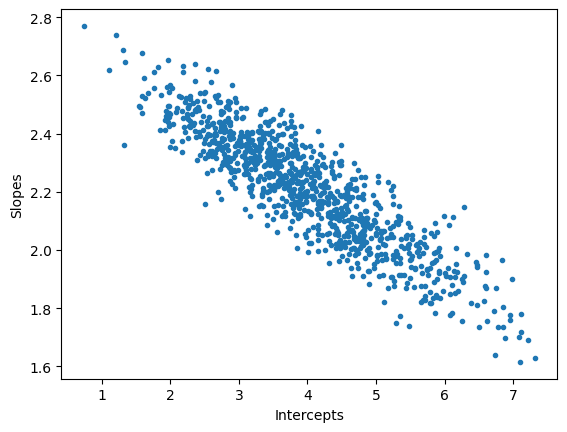

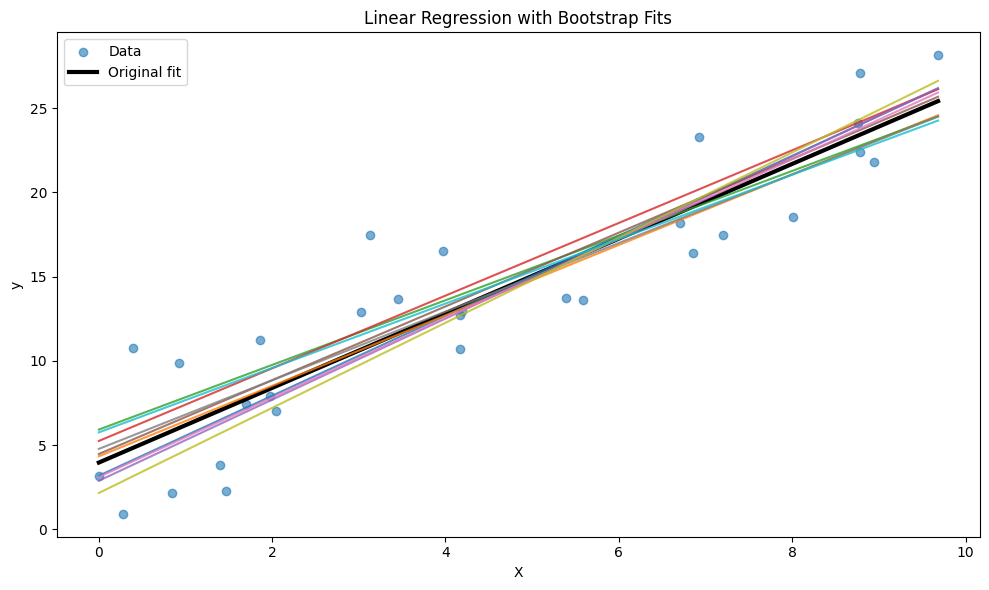

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Reproducibility
np.random.seed(1)

# -----------------------------
# 1) Create synthetic regression data
# -----------------------------
n = 30
X = np.random.uniform(0, 10, size=n).reshape(-1, 1)

beta_0 = 3.0
beta_1 = 2.5
sigma = 4.0

print(f"True pattern:")
print(f"  Intercept = {beta_0:.4f}")
print(f"  Slope     = {beta_1:.4f}")

# Normal error
eps = np.random.normal(0, sigma, size=n)
y = beta_0 + beta_1 * X.ravel() + eps

# -----------------------------
# 2) Fit the original linear regression
# -----------------------------
model = LinearRegression()
model.fit(X, y)
# sklearn, statsmodel

orig_intercept = model.intercept_
orig_slope = model.coef_[0]

print(f"Original fit:")
print(f"  Intercept = {orig_intercept:.4f}")
print(f"  Slope     = {orig_slope:.4f}")

# -----------------------------
# 3) Bootstrap the regression coefficients
# -----------------------------
B = 1000
boot_intercepts = np.zeros(B)
boot_slopes = np.zeros(B)

n_points = len(y) # n, from above

for b in range(B):
    # Resample indices with replacement
    idx = np.random.choice(n_points, size=n_points, replace=True)
    Xb = X[idx]
    yb = y[idx]

    boot_model = LinearRegression()
    boot_model.fit(Xb, yb)

    boot_intercepts[b] = boot_model.intercept_
    boot_slopes[b] = boot_model.coef_[0]

# Bootstrapped standard errors
boot_se_intercept = np.std(boot_intercepts, ddof=1)
boot_se_slope = np.std(boot_slopes, ddof=1)

plt.plot(boot_intercepts, boot_slopes, ".")
plt.xlabel("Intercepts")
plt.ylabel("Slopes")

print("\nBootstrap standard errors:")
print(f"  SE(Intercept) = {boot_se_intercept:.4f}")
print(f"  SE(Slope)     = {boot_se_slope:.4f}")

# -----------------------------
# 4) Plot the data and 10 bootstrap regression lines
# -----------------------------
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label="Data")

# Plot original fit
y_orig = model.predict(x_grid)
plt.plot(x_grid, y_orig, color="black", linewidth=3, label="Original fit")

# Plot 10 bootstrap fits
for b in range(10):
    y_boot = boot_intercepts[b] + boot_slopes[b] * x_grid.ravel()
    plt.plot(x_grid, y_boot, alpha=0.8, linewidth=1.5)

plt.title("Linear Regression with Bootstrap Fits")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# How often is the estimated coefficient above or below zero?

<div style="font-size: 20px;">
The scenario: </br> 
    
Are the sales having any effect at all?  If you can't tell if the effect is positive or negative, it might be zero.
    
After bootstrapping the regression model many times, your team wants to see how stable the estimated intercept and slope are. Instead of just looking at the average coefficient values, you also check how often each bootstrap estimate is positive, negative, or exactly zero to better understand the direction and consistency of the relationship between advertising spend and sales.
</div>

In [3]:
import numpy as np

# Assumes these arrays already exist from the bootstrap:
#   boot_intercepts
#   boot_slopes

def sign_percentages(arr):
    arr = np.asarray(arr)
    n = len(arr)

    pos = np.sum(arr > 0)
    neg = np.sum(arr < 0)
    zero = np.sum(arr == 0)

    return {
        "positive_pct": 100 * pos / n,
        "negative_pct": 100 * neg / n,
        "zero_pct": 100 * zero / n,
        "mean": np.mean(arr)
    }

intercept_stats = sign_percentages(boot_intercepts)
slope_stats = sign_percentages(boot_slopes)

print("Bootstrap sign percentages:")
print(f"Intercept:")
print(f"  Mean      = {intercept_stats['mean']:.6f}")
print(f"  Positive  = {intercept_stats['positive_pct']:.2f}%")
print(f"  Negative  = {intercept_stats['negative_pct']:.2f}%")
print(f"  Zero      = {intercept_stats['zero_pct']:.2f}%")

print(f"\nSlope:")
print(f"  Mean      = {slope_stats['mean']:.6f}")
print(f"  Positive  = {slope_stats['positive_pct']:.2f}%")
print(f"  Negative  = {slope_stats['negative_pct']:.2f}%")
print(f"  Zero      = {slope_stats['zero_pct']:.2f}%")

Bootstrap sign percentages:
Intercept:
  Mean      = 3.992228
  Positive  = 100.00%
  Negative  = 0.00%
  Zero      = 0.00%

Slope:
  Mean      = 2.207946
  Positive  = 100.00%
  Negative  = 0.00%
  Zero      = 0.00%


# Comparing bootstrap standard errors to OLS estimated standard errors

<div style="font-size: 20px;">
The situation:<br>

You're not sure if you're doing bootstrap standard errors right, and you want to check.
    
We can find the standard errors via bootstrapping or via statsmodels OLS estimates ("bse").  Do we get the same thing either way?
</div>

In [4]:
import numpy as np
import statsmodels.api as sm

# Assumes X and y from the previous code are still in memory.

# -----------------------------
# OLS fit with statsmodels
# -----------------------------
X_ols = sm.add_constant(X)  # adds intercept term
ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())

# Standard errors from OLS
ols_se_intercept = ols_model.bse[0]
ols_se_slope = ols_model.bse[1]

print("\nOLS standard errors (bse):")
print(f"  SE(Intercept) = {ols_se_intercept:.4f}")
print(f"  SE(Slope)     = {ols_se_slope:.4f}")

# -----------------------------
# Compare to bootstrap standard errors
# Assumes se_intercept and se_slope were computed earlier.
# -----------------------------
print("\nBootstrap vs OLS SE comparison:")
print(f"  Intercept: bootstrap = {boot_se_intercept:.4f}, OLS = {ols_se_intercept:.4f}")
print(f"  Slope:     bootstrap = {boot_se_slope:.4f}, OLS = {ols_se_slope:.4f}")

print("\nDifferences (bootstrap - OLS):")
print(f"  Intercept diff = {boot_se_intercept - ols_se_intercept:.4f}")
print(f"  Slope diff     = {boot_se_slope - ols_se_slope:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     135.1
Date:                Tue, 26 May 2026   Prob (F-statistic):           3.16e-12
Time:                        12:44:28   Log-Likelihood:                -75.888
No. Observations:                  30   AIC:                             155.8
Df Residuals:                      28   BIC:                             158.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9581      1.010      3.921      0.0

# Bootstrap SD of OLS standard errors

<div style="font-size: 20px;">
The situation:<br>

You want to know how much your OLS standard errors might be wrong by.
    
Can you use bootstrapping to check the errors of the standard errors?
</div>

In [7]:
import numpy as np
import statsmodels.api as sm

# Assumes X and y from the previous code are still in memory.
# Also assumes you already computed:
#   se_intercept, se_slope   (bootstrap SEs from coefficient resampling)
#   ols_se_intercept, ols_se_slope   (OLS bse from statsmodels)

np.random.seed(41)

# -----------------------------
# 1) Bootstrap the OLS standard errors themselves
#    For each bootstrap sample:
#      - resample (X, y) with replacement
#      - fit OLS
#      - record statsmodels bse for intercept and slope
# -----------------------------
B2 = 1000
boot_ols_bse_intercepts = np.zeros(B2)
boot_ols_bse_slopes = np.zeros(B2)

n = len(y)

for b in range(B2):
    idx = np.random.choice(n, size=n, replace=True)
    Xb = X[idx]
    yb = y[idx]

    Xb_ols = sm.add_constant(Xb)
    boot_ols_model = sm.OLS(yb, Xb_ols).fit()

    boot_ols_bse_intercepts[b] = boot_ols_model.bse[0]
    boot_ols_bse_slopes[b] = boot_ols_model.bse[1]

# -----------------------------
# 2) Estimate SD of the OLS standard errors across bootstrap trials
# -----------------------------
boot_sd_ols_bse_intercept = np.std(boot_ols_bse_intercepts, ddof=1)
boot_sd_ols_bse_slope = np.std(boot_ols_bse_slopes, ddof=1)

print("Bootstrap SD of the OLS standard errors:")
print(f"  SD[bse(Intercept)] = {boot_sd_ols_bse_intercept:.6f}")
print(f"  SD[bse(Slope)]     = {boot_sd_ols_bse_slope:.6f}")

# -----------------------------
# 3) Check whether the bootstrap SE is within 2 SDs of the OLS SE
# -----------------------------
intercept_diff = abs(boot_se_intercept - ols_se_intercept)
slope_diff = abs(boot_se_slope - ols_se_slope)

intercept_within_2sd = intercept_diff <= 2 * boot_sd_ols_bse_intercept
slope_within_2sd = slope_diff <= 2 * boot_sd_ols_bse_slope

print("\nComparison to OLS standard errors:")
print(f"Intercept:")
print(f"  bootstrap SE = {boot_se_intercept:.6f}")
print(f"  OLS bse      = {ols_se_intercept:.6f}")
print(f"  |difference| = {intercept_diff:.6f}")
print(f"  2 SD         = {2 * boot_sd_ols_bse_intercept:.6f}")
print(f"  Within 2 SD?  {intercept_within_2sd}")

print(f"\nSlope:")
print(f"  bootstrap SE = {boot_se_slope:.6f}")
print(f"  OLS bse      = {ols_se_slope:.6f}")
print(f"  |difference| = {slope_diff:.6f}")
print(f"  2 SD         = {2 * boot_sd_ols_bse_slope:.6f}")
print(f"  Within 2 SD?  {slope_within_2sd}")

Bootstrap SD of the OLS standard errors:
  SD[bse(Intercept)] = 0.118568
  SD[bse(Slope)]     = 0.025392

Comparison to OLS standard errors:
Intercept:
  bootstrap SE = 1.165051
  OLS bse      = 1.009586
  |difference| = 0.155465
  2 SD         = 0.237136
  Within 2 SD?  True

Slope:
  bootstrap SE = 0.193508
  OLS bse      = 0.190758
  |difference| = 0.002750
  2 SD         = 0.050785
  Within 2 SD?  True


# Fixed Effects



<div style="font-size: 20px;">
The situation:<br>

Three stores have different intercepts.  How to combine their data to estimate a common slope?
</div>

=== Fixed Effects via Demeaning ===
Coefficient on ad_spend: 2.9882
Standard error:          0.0443



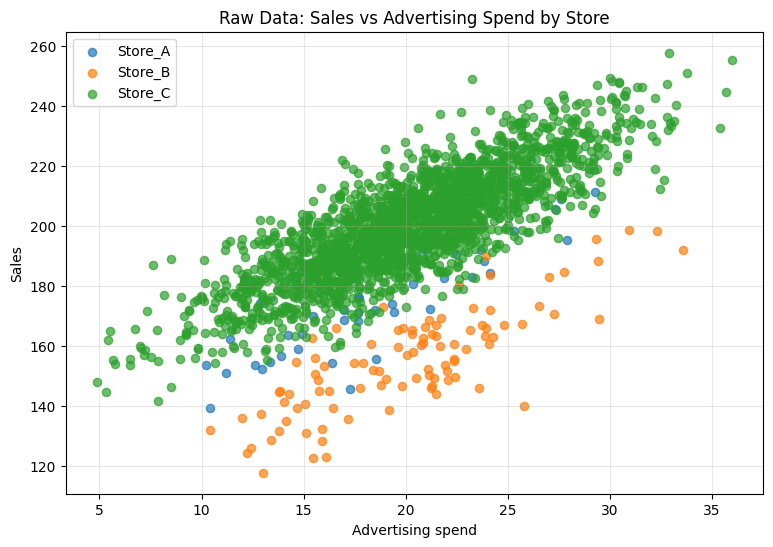

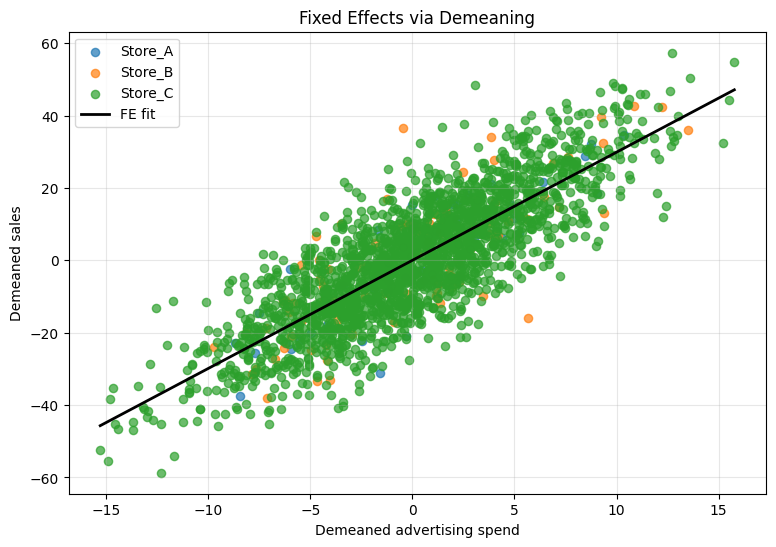

=== Store Means ===
         ad_spend    sales
store                     
Store_A    18.873  176.796
Store_B    20.112  155.984
Store_C    20.196  200.441


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ----------------------------
# 1) Simulate data
# ----------------------------
np.random.seed(42)

n_stores = 3
n_days_per_store = [50, 100, 2000]
store_names = ["Store_A", "Store_B", "Store_C"]

true_beta_ad_spend = 3.0
store_intercepts = {
    "Store_A": 120.0,
    "Store_B": 95.0,
    "Store_C": 140.0,
}

rows = []
for j, store in enumerate(store_names):
    ad_spend = np.random.normal(loc=20, scale=5, size=n_days_per_store[j])
    noise = np.random.normal(loc=0, scale=10, size=n_days_per_store[j])
    sales = store_intercepts[store] + true_beta_ad_spend * ad_spend + noise
    
    for i in range(n_days_per_store[j]):
        rows.append({
            "store": store,
            "day_id": f"{store}_{i+1}",
            "ad_spend": ad_spend[i],
            "sales": sales[i],
        })

df = pd.DataFrame(rows)

# ----------------------------
# 2) Demean within store
# ----------------------------
df["ad_spend_dm"] = df["ad_spend"] - df.groupby("store")["ad_spend"].transform("mean")
df["sales_dm"] = df["sales"] - df.groupby("store")["sales"].transform("mean")

# Fixed effects via demeaning: regress demeaned y on demeaned x, no intercept
X_dm = df[["ad_spend_dm"]]
y_dm = df["sales_dm"]

fe_model = sm.OLS(y_dm, X_dm).fit()

print("=== Fixed Effects via Demeaning ===")
print(f"Coefficient on ad_spend: {fe_model.params['ad_spend_dm']:.4f}")
print(f"Standard error:          {fe_model.bse['ad_spend_dm']:.4f}")
print()

# ----------------------------
# 3) Plot 1: raw data by store
# ----------------------------
colors = {
    "Store_A": "#1f77b4",
    "Store_B": "#ff7f0e",
    "Store_C": "#2ca02c",
}

plt.figure(figsize=(9, 6))
for store in store_names:
    sub = df[df["store"] == store]
    plt.scatter(
        sub["ad_spend"],
        sub["sales"],
        alpha=0.7,
        s=35,
        label=store,
        color=colors[store]
    )

plt.xlabel("Advertising spend")
plt.ylabel("Sales")
plt.title("Raw Data: Sales vs Advertising Spend by Store")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 4) Plot 2: demeaned data by store
# ----------------------------
plt.figure(figsize=(9, 6))
for store in store_names:
    sub = df[df["store"] == store]
    plt.scatter(
        sub["ad_spend_dm"],
        sub["sales_dm"],
        alpha=0.7,
        s=35,
        label=store,
        color=colors[store]
    )

# Add fitted line from demeaned regression
x_line = np.linspace(df["ad_spend_dm"].min(), df["ad_spend_dm"].max(), 200)
y_line = fe_model.params["ad_spend_dm"] * x_line
plt.plot(x_line, y_line, color="black", linewidth=2, label="FE fit")

plt.xlabel("Demeaned advertising spend")
plt.ylabel("Demeaned sales")
plt.title("Fixed Effects via Demeaning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 5) Optional: compare store means
# ----------------------------
store_means = df.groupby("store")[["ad_spend", "sales"]].mean()
print("=== Store Means ===")
print(store_means.round(3))

In [2]:
df

,store,day_id,ad_spend,sales,ad_spend_dm,sales_dm
0,Store_A,Store_A_1,22.483571,190.691552,3.610940,13.895852
1,Store_A,Store_A_2,19.308678,174.075213,0.436048,-2.720487
2,Store_A,Store_A_3,23.238443,182.946108,4.365812,6.150408
3,Store_A,Store_A_4,27.615149,208.962211,8.742519,32.166511
4,Store_A,Store_A_5,18.829233,186.797695,-0.043397,10.001994
...,...,...,...,...,...,...
2145,Store_C,Store_C_1996,22.612571,192.566033,2.416254,-7.875189
2146,Store_C,Store_C_1997,22.091991,195.725080,1.895674,-4.716143
2147,Store_C,Store_C_1998,27.007993,222.286656,6.811676,21.845434
2148,Store_C,Store_C_1999,23.252250,199.910204,3.055933,-0.531019


In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

results = []

for store in df["store"].unique():
    sub = df[df["store"] == store]
    X = sm.add_constant(sub[["ad_spend"]])
    y = sub["sales"]
    model = sm.OLS(y, X).fit()
    
    results.append({
        "store": store,
        "slope": model.params["ad_spend"],
        "se": model.bse["ad_spend"]
    })

store_results = pd.DataFrame(results)

# Average slope across stores
avg_slope = store_results["slope"].mean()

# Correct SE of the average slope, assuming the three store-specific slope estimates are independent
avg_se = np.sqrt((store_results["se"] ** 2).sum()) / len(store_results)

print("=== Store-specific slopes ===")
print(store_results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== Average across stores ===")
print(f"Average slope: {avg_slope:.4f}")
print(f"SE of average slope: {avg_se:.4f}")

=== Store-specific slopes ===
  store  slope     se
Store_A 3.2062 0.2687
Store_B 2.9167 0.2295
Store_C 2.9867 0.0458

=== Average across stores ===
Average slope: 3.0365
SE of average slope: 0.1188
